11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


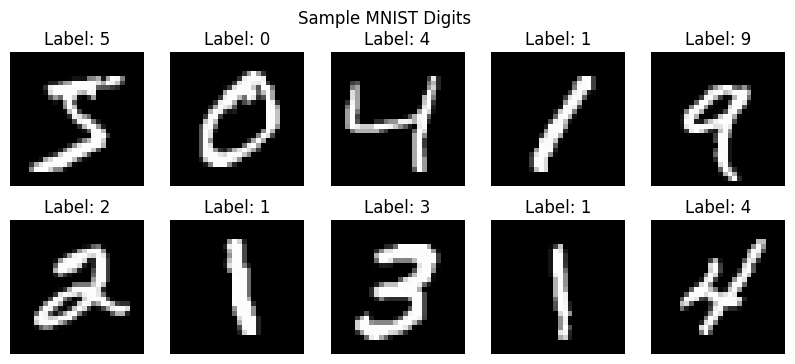

In [ ]:
#1
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Display some sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.show()

In [ ]:
#2
# Normalize images to values between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images to (28, 28, 1) for CNN input
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"x_train reshaped: {x_train.shape}")
print(f"x_test reshaped: {x_test.shape}")

# Convert labels to one-hot encoded format
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"y_train one-hot encoded: {y_train.shape}")
print(f"y_test one-hot encoded: {y_test.shape}")

x_train reshaped: (60000, 28, 28, 1)
x_test reshaped: (10000, 28, 28, 1)
y_train one-hot encoded: (60000, 10)
y_test one-hot encoded: (10000, 10)


In [ ]:
#3
# Build the CNN model
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)), # Recommended way to specify input shape
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten the output for the dense layer
    layers.Flatten(),

    # Dense layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 33ms/step - accuracy: 0.9211 - loss: 0.2545 - val_accuracy: 0.9813 - val_loss: 0.0618
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9694 - loss: 0.1011 - val_accuracy: 0.9872 - val_loss: 0.0422
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.9759 - loss: 0.0817 - val_accuracy: 0.9890 - val_loss: 0.0380
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9803 - loss: 0.0676 - val_accuracy: 0.9890 - val_loss: 0.0322
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9818 - loss: 0.0582 - val_accuracy: 0.9893 - val_loss: 0.0311
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9833 - loss: 0.0554 - val_accuracy: 0.9920 - val_loss: 0.0277
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9851 - loss: 0.0482 - val_accuracy: 0.9918 - val_loss: 0.0282
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9859 -

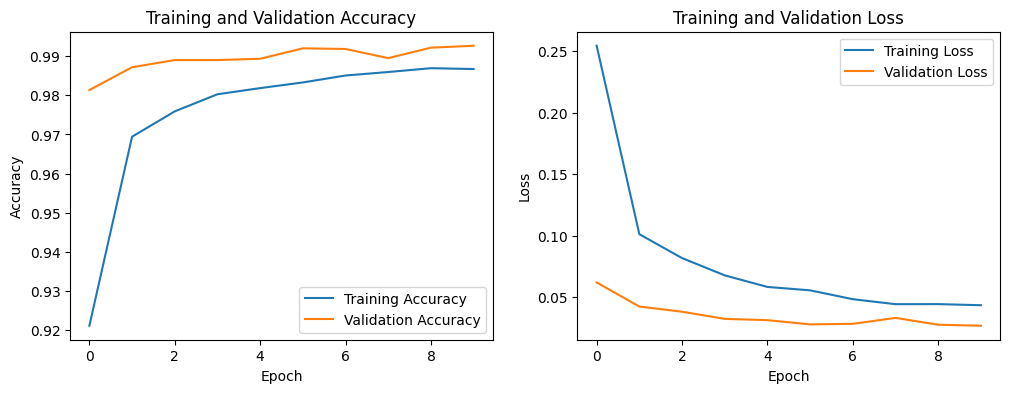

In [ ]:
#4
# Train the model
epochs = 10
batch_size = 32

# Explicitly split training data into training and validation sets with shuffling
from sklearn.model_selection import train_test_split
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, shuffle=True
)

history = model.fit(x_train_split, y_train_split,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_val_split, y_val_split), # Use explicit validation data
                    verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
#5
# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Check if accuracy meets the requirement
if accuracy >= 0.98:
    print("Model achieved at least 98% accuracy on the test set. Goal met!")
else:
    print("Model did not achieve 98% accuracy on the test set. Further training or model tuning might be needed.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9924 - loss: 0.0236
Test Loss: 0.0236
Test Accuracy: 0.9924
Model achieved at least 98% accuracy on the test set. Goal met!


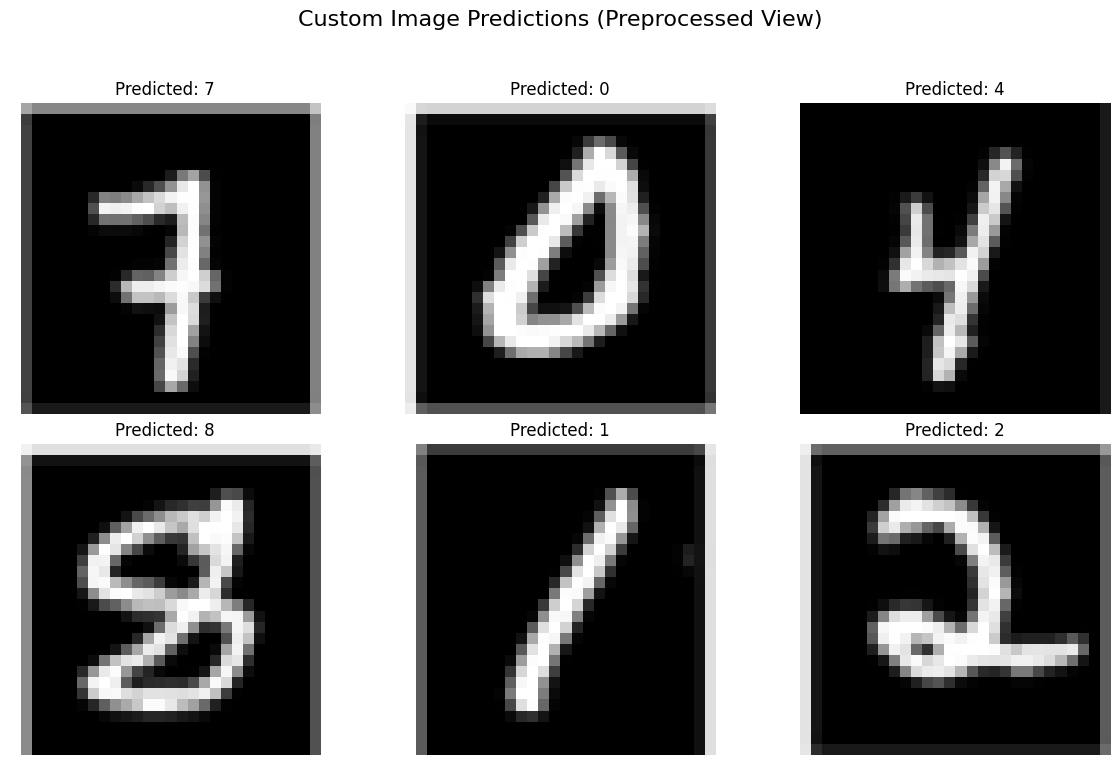


--- Custom Image Prediction Results ---
Image: 7new.png, Predicted Digit: 7
Image: 0new.png, Predicted Digit: 0
Image: 4new (2).png, Predicted Digit: 4
Image: 8new.png, Predicted Digit: 8
Image: 1new.png, Predicted Digit: 1
Image: 2new.png, Predicted Digit: 2


In [ ]:
# Step 6: Test the Model with Custom Images
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# List of custom image paths (assuming they are in /content/)
custom_image_paths = [
    '/content/7new.png',
    '/content/0new.png',
    '/content/4new (2).png',
    '/content/8new.png',
    '/content/1new.png',
    '/content/2new.png'
]

def preprocess_custom_image(image_path):
    # Load the image
    img = Image.open(image_path).convert('L') # Convert to grayscale
    # Resize to 28x28
    img = img.resize((28, 28))
    # Convert to numpy array and normalize
    img_array = np.asarray(img).astype('float32') / 255.0

    # --- IMPORTANT: MNIST images have WHITE digits on a BLACK background. --- #
    # --- If your custom images have DARK digits on a LIGHT background,      --- #
    # --- uncomment the line below to invert the colors:                     --- #
    # img_array = 1.0 - img_array # Invert colors

    # Reshape for model input (add channel and batch dimensions)
    model_input = np.expand_dims(img_array, axis=-1)
    model_input = np.expand_dims(model_input, axis=0)

    return img_array, model_input # Return both for display and prediction

plt.figure(figsize=(12, 8)) # Increased figure size for better visibility
predictions = []

for i, image_path in enumerate(custom_image_paths):
    preprocessed_img_display, processed_image_for_model = preprocess_custom_image(image_path)
    prediction = model.predict(processed_image_for_model, verbose=0) # verbose=0 to suppress per-image output
    predicted_class = np.argmax(prediction)
    predictions.append((image_path, predicted_class))

    # Display the preprocessed image and prediction
    plt.subplot(2, 3, i + 1) # Adjust subplot grid if needed
    plt.imshow(preprocessed_img_display, cmap='gray')
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')

plt.suptitle('Custom Image Predictions (Preprocessed View)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Custom Image Prediction Results ---")
for image_path, predicted_class in predictions:
    print(f"Image: {os.path.basename(image_path)}, Predicted Digit: {predicted_class}")